# 04 — Graph construction

We build a `torch_geometric.data.Data` object compatible with
`backend.perception.structural.gat_model.GraphEncoder`, then study the market
graph the way a structural analyst would — not just "does the encoder run".

**What this notebook now covers:**

* **Topology** — degree distribution, density, clustering, components,
  sector **assortativity**.
* **Systemic hubs** — eigenvector & betweenness centrality.
* **Hidden structure** — greedy-modularity **community detection** scored
  against the true sector labels (Adjusted Rand Index): does correlation alone
  recover sectors?
* **Market backbone** — the **Mantegna minimum spanning tree**.
* **Regime dependence** — how the correlation graph rewires between a calm and a
  stress window (the "diversification fails in a crash" effect, structurally).
* **GAT edge-attention** — which edges the trained-shape encoder actually leans
  on (`return_attention_weights=True`), plus a t-SNE of the output embeddings.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
import yfinance as yf
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score
from torch_geometric.data import Data

from backend.config.constants import NUM_SECTORS, SECTORS, TARGET_TICKERS, TICKER_TO_SECTOR

np.random.seed(42)
torch.manual_seed(42)
plt.style.use("dark_background")
COLORS = {"primary": "#4FC3F7", "success": "#66BB6A", "danger": "#EF5350",
          "warning": "#FFA726", "neutral": "#B0BEC5", "accent": "#ab47bc"}
SECTOR_PALETTE = dict(zip(SECTORS, plt.colormaps.get_cmap("tab10").colors))

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
CACHE = PROJECT_ROOT / "notebooks" / ".cache"
CACHE.mkdir(parents=True, exist_ok=True)

UNIVERSE = sorted(TARGET_TICKERS)
N = len(UNIVERSE)
idx_of = {t: i for i, t in enumerate(UNIVERSE)}
print(f"Universe: {N} tickers, {NUM_SECTORS} sectors")

/home/pyros05/Escritorio/lumina_project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Universe: 53 tickers, 8 sectors


## 1. Prices & returns (cached, shared with NB01)

In [2]:
def _dl():
    return yf.download(UNIVERSE, start="2018-01-01", end="2024-12-31", interval="1d",
                       auto_adjust=False, progress=False, threads=True)


path = CACHE / "daily_ohlcv_2018_2024.pkl"
raw = pd.read_pickle(path) if path.exists() else _dl()
if not path.exists():
    raw.to_pickle(path)
close = raw["Close"][UNIVERSE]
returns = np.log(close / close.shift(1)).dropna(how="all")
spy_ret = returns["SPY"]
print("Close:", close.shape, "| returns:", returns.shape)

Close: (2556, 53) | returns: (2555, 53)


## 2. Node features (32-dim)

`[ sector one-hot (8) | log-mcap | realised vol | β vs SPY | zeros … ]`. Market
cap is **simulated** (seeded) — flagged clearly; the other three are real. In
production these come from the fundamentals service.

In [3]:
sector_idx = {s: i for i, s in enumerate(SECTORS)}
features = np.zeros((N, 32), dtype=np.float32)
var_spy = float(spy_ret.var())
sim_logmcap = np.random.uniform(10, 13, size=N)  # SIMULATED, seeded

for i, t in enumerate(UNIVERSE):
    sec = TICKER_TO_SECTOR.get(t, "tech")
    features[i, sector_idx.get(sec, 0)] = 1.0
    features[i, NUM_SECTORS] = sim_logmcap[i] / 13.0                      # simulated
    features[i, NUM_SECTORS + 1] = float(returns[t].std() * np.sqrt(252)) # realised vol (real)
    features[i, NUM_SECTORS + 2] = float(returns[t].cov(spy_ret) / var_spy) if var_spy else 0.0  # beta (real)

print("Feature matrix:", features.shape, "(cols 0-7 sector, 8 sim-mcap, 9 vol, 10 beta)")

Feature matrix: (53, 32) (cols 0-7 sector, 8 sim-mcap, 9 vol, 10 beta)


## 3. Edges — static supply-chain + dynamic correlation

In [4]:
STATIC_EDGES = [("NVDA", "AAPL"), ("NVDA", "MSFT"), ("NVDA", "AMZN"), ("AMD", "MSFT"),
                ("AVGO", "AAPL"), ("MA", "V"), ("CVX", "XOM"), ("BAC", "JPM")]
CORR_THRESHOLD = 0.6

corr = returns[UNIVERSE].corr().to_numpy()
edges, edge_attrs, seen = [], [], set()
for src, tgt in STATIC_EDGES:
    if src in idx_of and tgt in idx_of:
        i, j = idx_of[src], idx_of[tgt]
        edges.append([i, j]); edge_attrs.append([0.0, 0.0, 1.0, 0.8]); seen.add((i, j))
for i in range(N):
    for j in range(N):
        if i == j or (i, j) in seen:
            continue
        r = float(corr[i, j])
        if abs(r) > CORR_THRESHOLD:
            edges.append([i, j]); edge_attrs.append([r, abs(r), 0.0, max(r, 0.0)]); seen.add((i, j))

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
edge_attr = torch.tensor(edge_attrs, dtype=torch.float32)
print(f"Edges: {edge_index.shape[1]} "
      f"({len(STATIC_EDGES)} static supply-chain + correlation |r|>{CORR_THRESHOLD})")

Edges: 232 (8 static supply-chain + correlation |r|>0.6)


## 4. Topology statistics

An undirected view of the graph. Assortativity by sector > 0 means same-sector
names preferentially connect — the structure the GAT is meant to exploit.

Nodes=53  Edges=118  Density=0.086
Avg degree=4.45  Avg clustering=0.568  Components=14
Sector assortativity=+0.396
Isolated nodes: ['ABBV', 'JNJ', 'LLY', 'MCD', 'MRK', 'NFLX', 'PFE', 'TSLA', 'UNH', 'WMT']


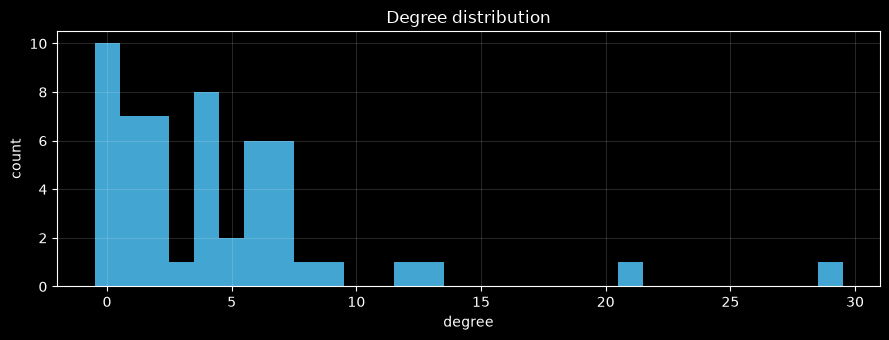

In [5]:
G = nx.Graph()
G.add_nodes_from(range(N))
for (i, j) in edges:
    G.add_edge(i, j)
for i, t in enumerate(UNIVERSE):
    G.nodes[i]["sector"] = TICKER_TO_SECTOR.get(t, "tech")

degrees = np.array([d for _, d in G.degree()])
print(f"Nodes={G.number_of_nodes()}  Edges={G.number_of_edges()}  "
      f"Density={nx.density(G):.3f}")
print(f"Avg degree={degrees.mean():.2f}  Avg clustering={nx.average_clustering(G):.3f}  "
      f"Components={nx.number_connected_components(G)}")
print(f"Sector assortativity={nx.attribute_assortativity_coefficient(G, 'sector'):+.3f}")
print(f"Isolated nodes: {[UNIVERSE[i] for i in range(N) if G.degree(i) == 0] or 'none'}")

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(degrees, bins=range(0, degrees.max() + 2), color=COLORS["primary"], alpha=0.85, align="left")
ax.set_xlabel("degree"); ax.set_ylabel("count"); ax.set_title("Degree distribution")
ax.grid(alpha=0.15)
plt.tight_layout(); plt.show()

## 5. Systemic hubs — centrality

Eigenvector centrality flags names embedded in densely-connected clusters;
betweenness flags bridges between clusters. The top names are the systemic
risk-transmission hubs.

In [6]:
# Eigenvector centrality is only well-defined on a connected graph, and the
# |r|>0.6 graph can leave low-correlation names isolated. Compute it on the
# giant component and default the rest to 0.
eig = {i: 0.0 for i in range(N)}
if G.number_of_edges():
    giant = max(nx.connected_components(G), key=len)
    eig.update(nx.eigenvector_centrality_numpy(G.subgraph(giant)))
bet = nx.betweenness_centrality(G)
cent = pd.DataFrame({
    "ticker": [UNIVERSE[i] for i in range(N)],
    "sector": [TICKER_TO_SECTOR.get(UNIVERSE[i], "?") for i in range(N)],
    "degree": [G.degree(i) for i in range(N)],
    "eigenvector": [eig[i] for i in range(N)],
    "betweenness": [bet[i] for i in range(N)],
}).set_index("ticker")
print("Top 8 by eigenvector centrality:")
print(cent.sort_values("eigenvector", ascending=False).head(8).round(3).to_string())
print("\nTop 5 bridges by betweenness:")
print(cent.sort_values("betweenness", ascending=False).head(5)[["sector", "betweenness"]].round(3).to_string())

Top 8 by eigenvector centrality:
            sector  degree  eigenvector  betweenness
ticker                                              
SPY          index      29        0.450        0.196
QQQ          index      21        0.364        0.076
MSFT          tech      13        0.283        0.010
BLK     financials      12        0.251        0.014
NVDA          tech       9        0.212        0.003
AAPL          tech       7        0.188        0.001
MS      financials       8        0.187        0.004
MA      financials       6        0.175        0.000

Top 5 bridges by betweenness:
            sector  betweenness
ticker                         
SPY          index        0.196
QQQ          index        0.076
BLK     financials        0.014
MSFT          tech        0.010
GOOGL         tech        0.005


## 6. Community detection vs sectors

Run greedy-modularity community detection on the correlation graph and score the
partition against the *true* sector labels with the Adjusted Rand Index
(ARI: 1 = identical, 0 = chance). A high ARI means price co-movement alone
rediscovers the sector taxonomy.

In [7]:
from networkx.algorithms.community import greedy_modularity_communities

comms = list(greedy_modularity_communities(G))
comm_of = {n: c for c, nodes in enumerate(comms) for n in nodes}
detected = [comm_of.get(i, -1) for i in range(N)]
true_sec = [sector_idx.get(TICKER_TO_SECTOR.get(UNIVERSE[i], "tech"), -1) for i in range(N)]
ari = adjusted_rand_score(true_sec, detected)
print(f"Detected {len(comms)} communities | ARI vs sectors = {ari:.3f}")
for c, nodes in enumerate(sorted(comms, key=len, reverse=True)[:6]):
    members = [UNIVERSE[i] for i in nodes]
    secs = pd.Series([TICKER_TO_SECTOR.get(m, "?") for m in members]).value_counts()
    print(f"  community {c} (n={len(members)}): dominant={secs.index[0]} "
          f"({secs.iloc[0]}/{len(members)}) -> {members[:6]}{'…' if len(members) > 6 else ''}")

Detected 16 communities | ARI vs sectors = 0.509
  community 0 (n=16): dominant=tech (13/16) -> ['AAPL', 'ADBE', 'AMD', 'AMZN', 'AVGO', 'CRM']…
  community 1 (n=9): dominant=financials (7/9) -> ['BAC', 'BLK', 'C', 'GS', 'HD', 'WFC']…
  community 2 (n=7): dominant=consumer_discretionary (2/7) -> ['NKE', 'ORCL', 'TMO', 'SBUX', 'COST', 'SPY']…
  community 3 (n=5): dominant=energy (5/5) -> ['SLB', 'XOM', 'COP', 'CVX', 'EOG']
  community 4 (n=3): dominant=consumer_staples (3/3) -> ['PEP', 'PG', 'KO']
  community 5 (n=3): dominant=crypto (3/3) -> ['BTC-USD', 'ETH-USD', 'SOL-USD']


## 7. Market backbone — Mantegna minimum spanning tree

Mantegna (1999): convert correlation to distance `d = sqrt(2(1−ρ))` and take the
MST of the complete graph. The result is the skeleton of the market — branches
tend to be sectors hanging off mega-cap hubs.

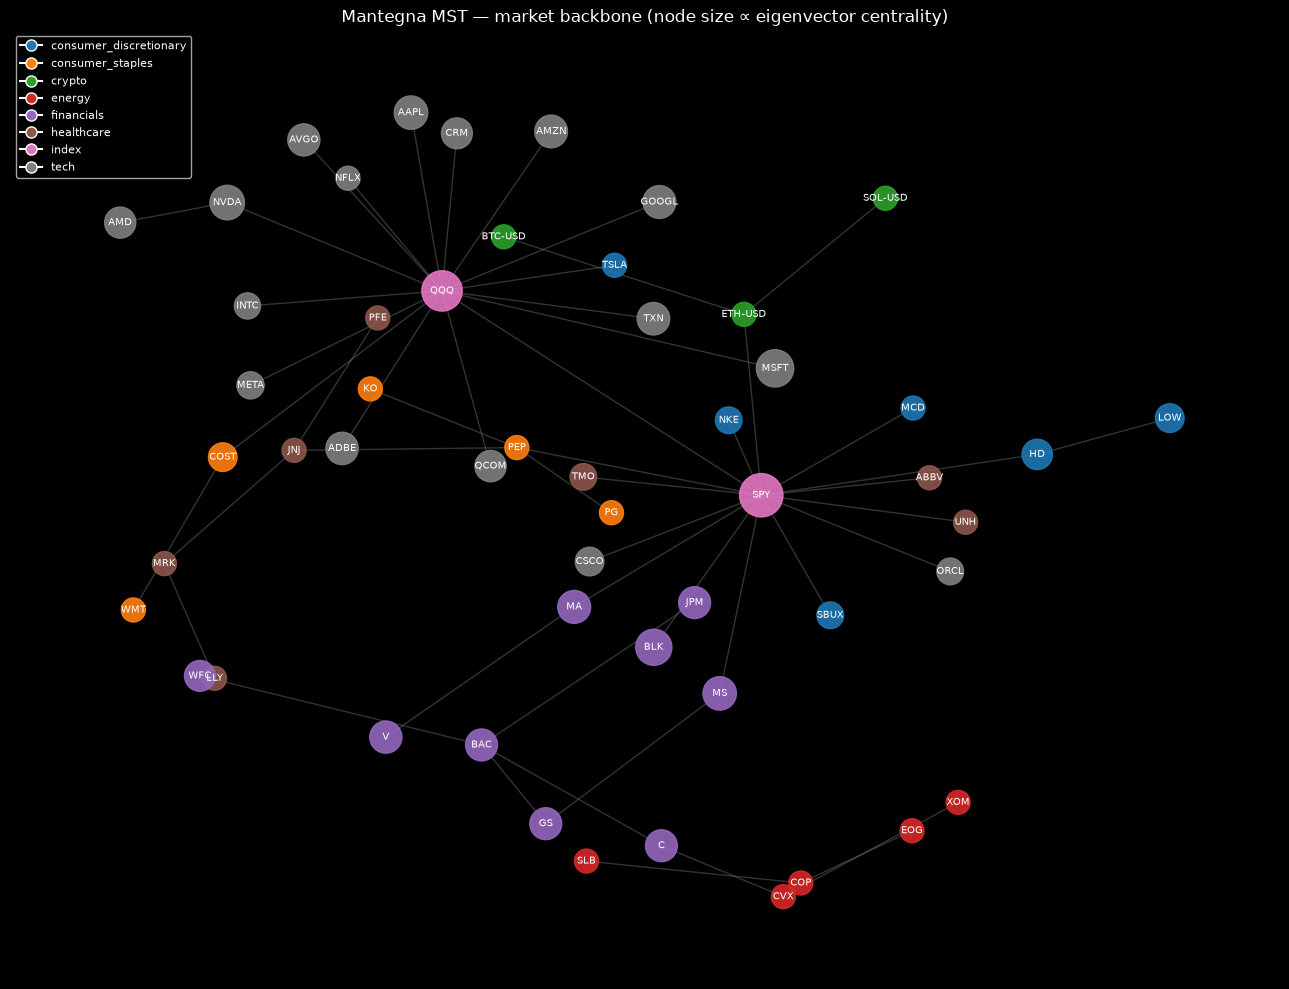

In [8]:
dist = np.sqrt(2 * (1 - np.clip(corr, -1, 1)))
Gc = nx.Graph()
for i in range(N):
    for j in range(i + 1, N):
        Gc.add_edge(i, j, weight=float(dist[i, j]))
mst = nx.minimum_spanning_tree(Gc)

plt.figure(figsize=(13, 10))
pos = nx.spring_layout(mst, seed=42, k=0.6, iterations=80)
node_colors = [SECTOR_PALETTE.get(TICKER_TO_SECTOR.get(UNIVERSE[i], "tech")) for i in range(N)]
node_sizes = [300 + 1500 * cent["eigenvector"].iloc[i] for i in range(N)]
nx.draw_networkx_edges(mst, pos, alpha=0.4, edge_color="gray")
nx.draw_networkx_nodes(mst, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(mst, pos, {i: UNIVERSE[i] for i in range(N)}, font_size=7, font_color="white")
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=SECTOR_PALETTE[s], label=s, markersize=8)
           for s in SECTORS]
plt.legend(handles=handles, loc="upper left", fontsize=8)
plt.title("Mantegna MST — market backbone (node size ∝ eigenvector centrality)")
plt.axis("off"); plt.tight_layout(); plt.show()

## 8. Regime dependence — calm vs stress rewiring

Rebuild the correlation graph on a calm window (2019 H2) and a stress window
(COVID crash, 2020 H1). We expect mean correlation and edge density to jump in
the stress regime — diversification quietly evaporating.

Calm   (2019 H2)  : mean |r|=0.338  edges=132
Stress (2020 H1)  : mean |r|=0.628  edges=905
Edge-set Jaccard overlap: 14.46%  (low ⇒ the graph rewired)


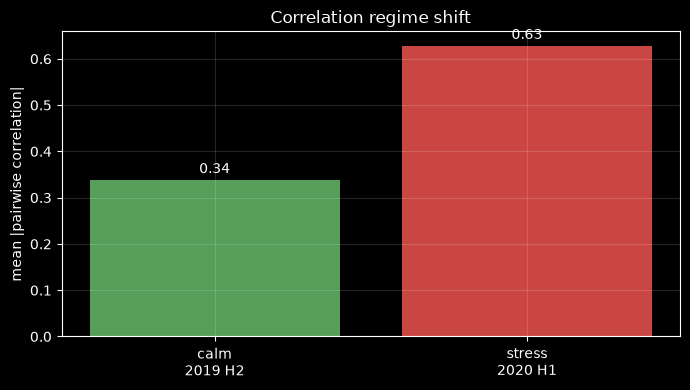

In [9]:
def regime_graph(window_slice, thresh=0.6):
    r = returns[UNIVERSE].loc[window_slice].dropna(how="all")
    c = r.corr().to_numpy()
    es = {(i, j) for i in range(N) for j in range(i + 1, N) if abs(c[i, j]) > thresh}
    mean_abs = float(np.nanmean(np.abs(c[np.triu_indices(N, 1)])))
    return es, mean_abs, len(es)


calm_e, calm_r, calm_n = regime_graph(slice("2019-06-01", "2019-12-31"))
str_e, str_r, str_n = regime_graph(slice("2020-02-01", "2020-06-30"))
jacc = len(calm_e & str_e) / len(calm_e | str_e)
print(f"Calm   (2019 H2)  : mean |r|={calm_r:.3f}  edges={calm_n}")
print(f"Stress (2020 H1)  : mean |r|={str_r:.3f}  edges={str_n}")
print(f"Edge-set Jaccard overlap: {jacc:.2%}  (low ⇒ the graph rewired)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["calm\n2019 H2", "stress\n2020 H1"], [calm_r, str_r],
       color=[COLORS["success"], COLORS["danger"]], alpha=0.85)
ax.set_ylabel("mean |pairwise correlation|")
ax.set_title("Correlation regime shift"); ax.grid(alpha=0.15)
for i, v in enumerate([calm_r, str_r]):
    ax.annotate(f"{v:.2f}", (i, v), textcoords="offset points", xytext=(0, 5), ha="center")
plt.tight_layout(); plt.show()

## 9. Encoder smoke-run + GAT edge-attention

Run the `GraphEncoder` and ask it which edges it attends to most
(`return_attention_weights=True`). The top-attention edges are the relationships
the structural stream relies on — exactly what the Arena attribution extractor
records as `gat_edges_top`.

In [10]:
from backend.perception.structural.gat_model import GraphEncoder

data = Data(x=torch.from_numpy(features), edge_index=edge_index, edge_attr=edge_attr)
gnn = GraphEncoder(node_feat_dim=32, hidden_dim=64, output_dim=32).eval()
with torch.no_grad():
    z, alpha_ei, alpha = gnn(data.x, data.edge_index, data.edge_attr, return_attention_weights=True)

print("Output embedding shape:", tuple(z.shape))
assert z.shape == (N, 32)

# Drop self-loops, rank remaining edges by attention.
ei = alpha_ei.numpy(); aw = alpha.numpy().ravel()
mask = ei[0] != ei[1]
pairs = sorted(zip(ei[0][mask], ei[1][mask], aw[mask]), key=lambda p: -p[2])
seen_top, top = set(), []
for s, t, a in pairs:
    key = frozenset((int(s), int(t)))
    if key in seen_top:
        continue
    seen_top.add(key); top.append((int(s), int(t), float(a)))
    if len(top) == 12:
        break
print("\nTop-12 attended edges:")
for s, t, a in top:
    print(f"  {UNIVERSE[s]:>6} → {UNIVERSE[t]:<6}  α={a:.3f}  "
          f"({TICKER_TO_SECTOR.get(UNIVERSE[s])}/{TICKER_TO_SECTOR.get(UNIVERSE[t])})")
print("PASS — graph + GATv2 wired correctly; edge-attention extracted.")

Output embedding shape: (53, 32)

Top-12 attended edges:
     SPY → TMO     α=0.581  (index/healthcare)
     SPY → ORCL    α=0.536  (index/tech)
  ETH-USD → BTC-USD  α=0.525  (crypto/crypto)
     QQQ → INTC    α=0.504  (index/tech)
     SPY → SBUX    α=0.479  (index/consumer_discretionary)
  ETH-USD → SOL-USD  α=0.478  (crypto/crypto)
     SPY → NKE     α=0.477  (index/consumer_discretionary)
     QQQ → META    α=0.350  (index/tech)
     QQQ → CSCO    α=0.344  (index/tech)
     QQQ → COST    α=0.343  (index/consumer_staples)
     SPY → CSCO    α=0.341  (index/tech)
      PG → KO      α=0.334  (consumer_staples/consumer_staples)
PASS — graph + GATv2 wired correctly; edge-attention extracted.


## 10. Output-embedding geometry

t-SNE of the 32-d GraphEncoder node embeddings. Even untrained, the sector
one-hot in the node features should make same-sector nodes cluster.

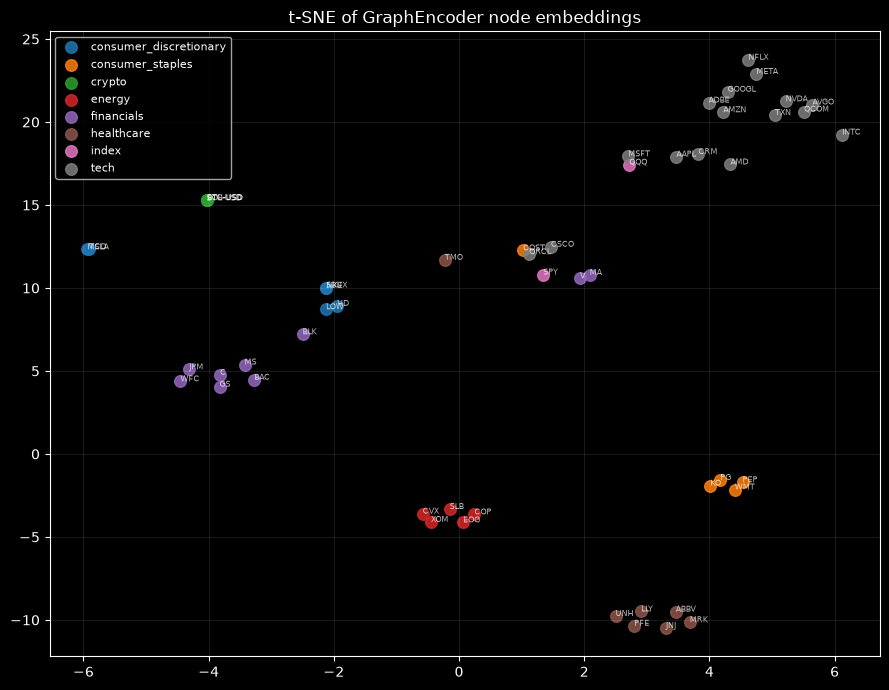

In [11]:
emb2d = TSNE(n_components=2, perplexity=8, random_state=42).fit_transform(z.numpy())
plt.figure(figsize=(9, 7))
for s in SECTORS:
    m = [i for i in range(N) if TICKER_TO_SECTOR.get(UNIVERSE[i], "tech") == s]
    if m:
        plt.scatter(emb2d[m, 0], emb2d[m, 1], color=SECTOR_PALETTE[s], label=s, s=70, alpha=0.85)
for i in range(N):
    plt.annotate(UNIVERSE[i], (emb2d[i, 0], emb2d[i, 1]), fontsize=6, alpha=0.7)
plt.legend(fontsize=8); plt.title("t-SNE of GraphEncoder node embeddings")
plt.grid(alpha=0.1); plt.tight_layout(); plt.show()